# Nigeria Power Sector Investment Brief 2024

**Data Sources:** Nigerian Electricity Regulatory Commission (NERC) Annual Report 2024,
Central Bank of Nigeria (CBN), National Bureau of Statistics (NBS), World Bank

**Objective:** To identify priority investment opportunities in Nigeria's power sector 
by analysing the generation capacity gaps, distribution performance, billing efficiency, 
and renewable energy potential across the 2021–2024 period.

**Audience:** Development finance analysts, energy sector investors, and policy 
stakeholders evaluating capital deployment opportunities in Nigerian infrastructure.

**Tools:** Python, Pandas, Matplotlib, SQLite

In [9]:
# Importing libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Creating database
conn = sqlite3.connect('nigeria_investment.db')

# Load all csv
generation = pd.read_csv('generation_by_fuel.csv')
discos_energy = pd.read_csv('discos_energy_2021_2024.csv')
discos_billing = pd.read_csv('discos_billing_2024.csv')
plant_availability = pd.read_csv('plant_availability_2024.csv')

# Convert to database
generation.to_sql('generation',conn, if_exists = 'replace', index = False)
discos_energy.to_sql('discos_energy',conn, if_exists = 'replace', index = False)
discos_billing.to_sql('discos_billing',conn, if_exists = 'replace', index = False)
plant_availability.to_sql('plant_availability',conn, if_exists = 'replace', index = False)

print("Database ready")
print(f"Tables loaded: generation, discos_energy, discos_billing, plant_availability")

Database ready
Tables loaded: generation, discos_energy, discos_billing, plant_availability


In [10]:
# Total installed vs available capacity
total_installed = plant_availability['installed_capacity_mw'].sum()
total_available = plant_availability['avg_available_capacity_mw'].sum()
total_lost = total_installed - total_available
utilization = (total_available / total_installed) * 100

print(f"Total installed capacity : {total_installed:,.0f} Mw")
print(f"Total available capacity : {total_available:,.0f} Mw")
print(f"Lost capacity : {total_lost:,.0f} Mw")
print(f"System utilization : {utilization:.1f}%")

Total installed capacity : 9,179 Mw
Total available capacity : 4,529 Mw
Lost capacity : 4,650 Mw
System utilization : 49.3%


In [11]:
# Plants with the worst availability - Top rehabilitation targets
poor_performers = plant_availability[plant_availability['paf_pct'] < 45].copy()
poor_performers['lost_capacity_mw'] = plant_availability['installed_capacity_mw'] - plant_availability['avg_available_capacity_mw']
poor_performers = poor_performers[['plant', 'installed_capacity_mw', 'avg_available_capacity_mw', 'lost_capacity_mw', 'paf_pct']].sort_values('paf_pct')

print("Priority Rehabilitation Targets (PAF below 45%):")
print(poor_performers.to_string(index=False))

Priority Rehabilitation Targets (PAF below 45%):
       plant  installed_capacity_mw  avg_available_capacity_mw  lost_capacity_mw  paf_pct
    Igbafo_1                     45                      15.98             29.02    35.51
Olorunsogo_1                    335                     121.61            213.39    36.30
    Geregu_1                    435                     159.14            275.86    36.58
  Omotosho_1                    335                     124.20            210.80    37.07
Ibom_Power_1                    190                      72.27            117.73    38.04
    Rivers_1                    180                      69.12            110.88    38.40
     Delta_1                    900                     350.95            549.05    38.99
    Geregu_2                    435                     179.01            255.99    41.15
     Egbin_1                   1320                     558.35            761.65    42.30
      Afam_2                    650                

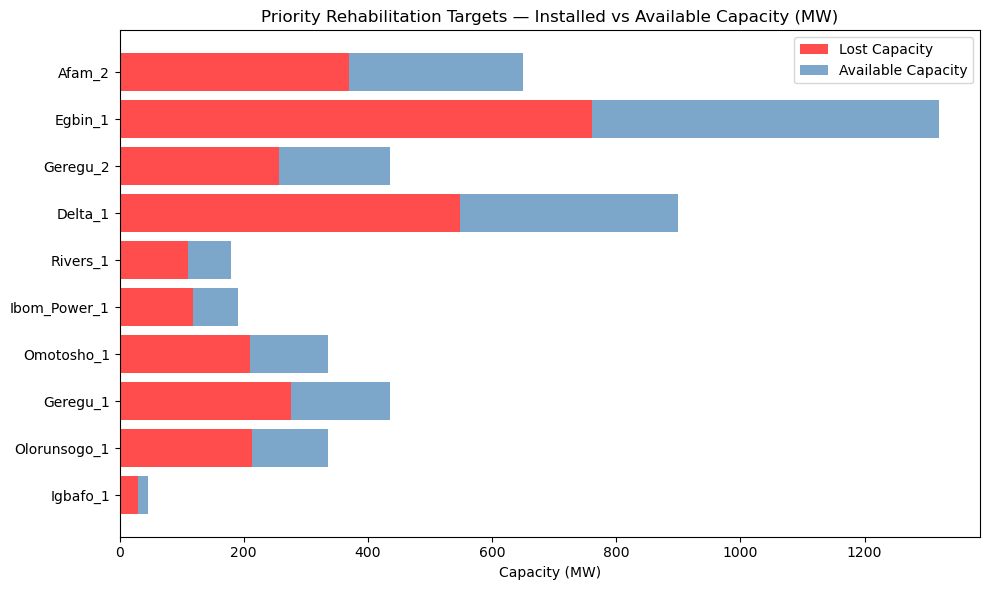

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(poor_performers['plant'], poor_performers['lost_capacity_mw'], color='red', alpha=0.7)
ax.barh(poor_performers['plant'], poor_performers['avg_available_capacity_mw'], 
        left=poor_performers['lost_capacity_mw'], color='steelblue', alpha=0.7)

ax.set_title('Priority Rehabilitation Targets — Installed vs Available Capacity (MW)')
ax.set_xlabel('Capacity (MW)')
ax.legend(['Lost Capacity', 'Available Capacity'])
plt.tight_layout()
plt.show()

In [13]:
billing = pd.read_csv('discos_billing_2024.csv')

billing['billing_gap_gwh'] = billing['energy_received_gwh'] - billing['energy_billed_gwh']
billing['billing_gap_pct'] = ((billing['billing_gap_gwh']) / billing['energy_received_gwh'] * 100).round(1)

billing_sorted = billing.sort_values('billing_efficiency_pct')

print(billing_sorted[['disco', 'energy_received_gwh', 'energy_billed_gwh', 'billing_efficiency_pct', 'billing_gap_gwh']].to_string(index=False))

        disco  energy_received_gwh  energy_billed_gwh  billing_efficiency_pct  billing_gap_gwh
       Kaduna              1661.27            1050.62                   63.24           610.65
          Jos              1470.44            1055.77                   71.80           414.67
        Abuja              4498.57            3510.00                   78.02           988.57
        Enugu              2364.63            1864.77                   78.86           499.86
         Kano              1687.08            1351.88                   80.13           335.20
        Ikeja              4558.58            3803.34                   83.43           755.24
Port Harcourt              2199.67            1867.71                   84.91           331.96
        Benin              2591.83            2207.87                   85.19           383.96
         Yola               644.59             567.52                   88.04            77.07
       Ibadan              3573.60            3172

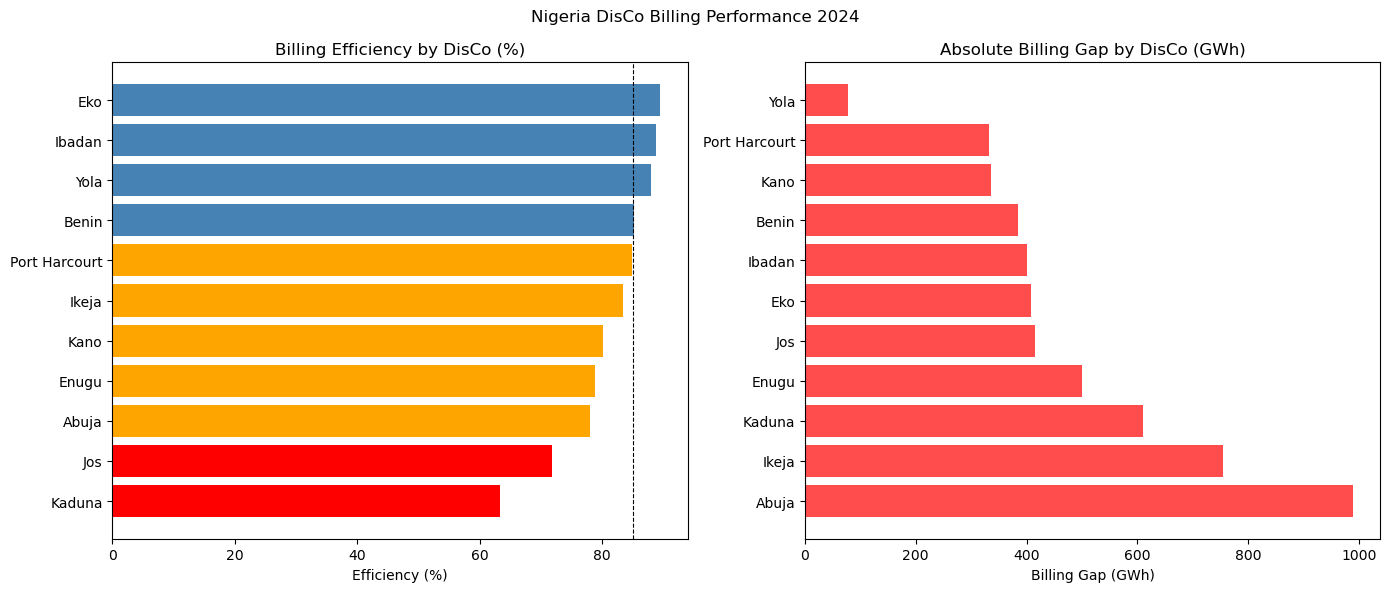

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Chart 1
colors = ['red' if x < 75 else 'orange' if x < 85 else 'steelblue' for x in billing_sorted['billing_efficiency_pct']]
axes[0].barh(billing_sorted['disco'], billing_sorted['billing_efficiency_pct'], color=colors)
axes[0].axvline(x=85, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Billing Efficiency by DisCo (%)')
axes[0].set_xlabel('Efficiency (%)')

# Chart 2 - Absolute billing gap
billing_gap_sorted = billing.sort_values('billing_gap_gwh', ascending=False)
axes[1].barh(billing_gap_sorted['disco'], billing_gap_sorted['billing_gap_gwh'], color='red', alpha=0.7)
axes[1].set_title('Absolute Billing Gap by DisCo (GWh)')
axes[1].set_xlabel('Billing Gap (GWh)')

plt.suptitle('Nigeria DisCo Billing Performance 2024')
plt.tight_layout()
plt.show()

In [15]:
solar_data = pd.DataFrame({
    'state': ['Sokoto', 'Borno', 'Kano', 'Kaduna', 'Niger', 
              'Lagos', 'Rivers', 'Oyo', 'Anambra', 'Delta'],
    'region': ['North', 'North', 'North', 'North', 'North',
               'South', 'South', 'South', 'South', 'South'],
    'solar_irradiance_kwh_m2': [6.8, 6.5, 6.2, 5.9, 5.7,
                                 4.8, 4.5, 5.1, 4.9, 4.6],
    'electricity_access_pct': [19, 22, 45, 38, 31,
                                72, 61, 55, 63, 58]
})

solar_data.to_sql('solar', conn, if_exists='replace', index=False)

# North vs South comparison
regional = solar_data.groupby('region').agg(
    avg_irradiance=('solar_irradiance_kwh_m2', 'mean'),
    avg_access=('electricity_access_pct', 'mean')
).round(2)

print(regional)
print(f"\nSolar correlation with access: {solar_data['solar_irradiance_kwh_m2'].corr(solar_data['electricity_access_pct']):.2f}")

        avg_irradiance  avg_access
region                            
North             6.22        31.0
South             4.78        61.8

Solar correlation with access: -0.91


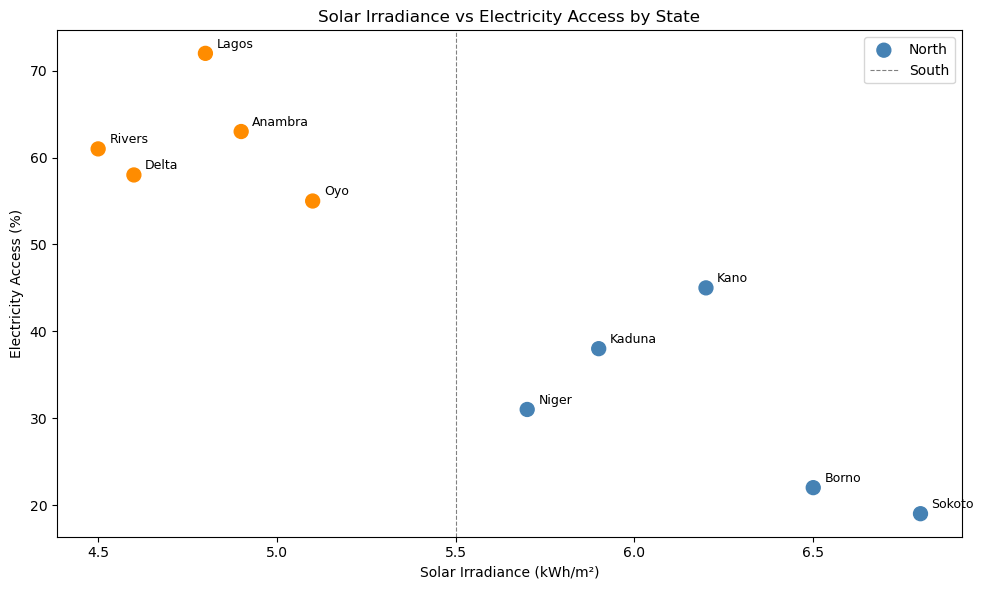

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue' if r == 'North' else 'darkorange' for r in solar_data['region']]
ax.scatter(solar_data['solar_irradiance_kwh_m2'], solar_data['electricity_access_pct'], 
           c=colors, s=100)

# Label each point with state name
for _, row in solar_data.iterrows():
    ax.annotate(row['state'], 
                (row['solar_irradiance_kwh_m2'], row['electricity_access_pct']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_title('Solar Irradiance vs Electricity Access by State')
ax.set_xlabel('Solar Irradiance (kWh/m²)')
ax.set_ylabel('Electricity Access (%)')
ax.axvline(x=5.5, color='gray', linewidth=0.8, linestyle='--')
ax.legend(['North', 'South'])
plt.tight_layout()
plt.show()

## Executive Summary

We ran an analysis on the Nigeria's power sector from 2021 to 2024 using publicly available data from the Nigerian Electricity Regulatory Commission (NERC). The analysis covers the generation capacity, billing efficiency, distribution performance and renewable energy potential across various Nigerian states.

### Key Findings

- All of Nigeria's grid-connected power plants only operated at 49.3% of the installed capacity in 2024, with 4,650MW effectively unavailable due to poor plant availability.
- Six of the eleven distribution companies received less energy in 2024 than in 2021, with Kaduna and Yola declining by 28.5%.
- The Northern states average 6.22kWh/(m^2) of solar irradiance compared to the 4.78kWh/(m^2) in the South, yet the electricity access in the North stands at only 31% compared to the 61.8% recorded in the South.

### Investment Recommendations

1. The underperforming power plants, particularly Egbin (1,320 MW installed, 42% availability) and Delta (900 MW, 39% availability) needs an immediate rehabilitation .
2. Improvement in the billing infrastructures in the Abuja and Kaduna Discos, as the Discos with the highest energy lossess.
3. Sokoto, Borno and Kano, the areas with the highest solar irradiance averaging 6.5kWh/(m^2), lowest electricity access below 25% and highest unmet demand, needs large scale solar investment.